In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from thop import profile, clever_format
from torch.optim.lr_scheduler import SequentialLR, StepLR

import csv
import time
import json
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe
from loadData.split_data import HyperX2
from loadData.dataAugmentation import DataAugmentationDINO2

from utils import util, trainer, tester, infoNCE, CELoss
from models import resNet2, heads, vision_transformer, automaticWeightedLoss
from models.MS2CANet import pymodel


using GPU 1


In [2]:
args = opt.get_args()
# args.dataset_name = "Houston_2018"
args.dataset_name = "Houston_2013"
# args.dataset_name ="Berlin"

args.backbone = "resNet"
# args.backbone = "dino"
# args.backbone = "MS2CANet"
# args.awl = True

args.awl = False
args.epochs = 50
args.local_crops_number = 0

if args.backbone == "resNet":
	args.patch_size = 13
	args.randomCrop = 11
	args.batch_size = 512
	args.learning_rate = 1e-3
	args.weight_decay = 1e-6
	args.pca = True
	args.components = 15
	
	args.schedule = True
	args.step_size = 5
	args.gamma = 0.3

elif args.backbone == "MS2CANet":
	args.patch_size = 11
	args.randomCrop = 11
	args.batch_size = 64
	args.learning_rate = 0.001
	args.pca = True
	args.components = 20
	args.schedule = True
	args.step_size = 5
	args.gamma = 0.3

pca is used


<Figure size 1200x800 with 0 Axes>

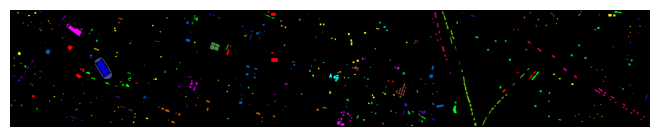

print_data_info : ---->
class 1 	 178 	 20 	 1053
class 2 	 171 	 19 	 1064
class 3 	 173 	 19 	 505
class 4 	 169 	 19 	 1056
class 5 	 167 	 19 	 1056
class 6 	 164 	 18 	 143
class 7 	 176 	 20 	 1072
class 8 	 172 	 19 	 1053
class 9 	 174 	 19 	 1059
class 10 	 172 	 19 	 1036
class 11 	 163 	 18 	 1054
class 12 	 173 	 19 	 1041
class 13 	 166 	 18 	 285
class 14 	 163 	 18 	 247
class 15 	 168 	 19 	 473
total     	 2549 	 283 	 12197
img11 (363, 1919, 15) img2 (363, 1919, 1) train_gt (363, 1919) val_gt (363, 1919) test_gt (363, 1919) data_gt (363, 1919)
15 (363, 1919) 2549


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = True
args.data_info_start = 1
args.show_gt = True
args.train_ratio = 0.9
args.split_type = "ratio"

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)
print("img11", img1.shape, "img2", img2.shape, \
	  "train_gt", train_gt.shape, \
	  "val_gt", val_gt.shape, \
	  "test_gt", test_gt.shape, \
	  "data_gt", data_gt.shape)


height, wigth, data1_bands = img1.shape
height, wigth, data2_bands = img2.shape
transform = DataAugmentationDINO2(args)

args.remove_zero_labels = False
contrastive_dataset = HyperX2(img1, img2, data_gt, transform=transform, 
					   patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)


args.remove_zero_labels = True
train_dataset = HyperX2(img1, img2, train_gt, transform=None, 
						patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
val_dataset = HyperX2(img1, img2, val_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
test_dataset = HyperX2(img1, img2, test_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
contrastive_loader = DataLoader(contrastive_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

class_num = np.max(train_gt)
print(class_num, train_gt.shape, len(train_loader.dataset))

In [4]:
for x11, x12, x21, x22, y in contrastive_loader:
    print("x11.shape, x12.shape", x11.shape, x12.shape, len(x11))
    print("x21.shape, x22.shape", x21.shape, x22.shape, len(x21))
    break

for x11, x21, y in train_loader:
    print("x11.shape", x11.shape)
    print("x21.shape", x21.shape)
    break

x11.shape, x12.shape torch.Size([512, 15, 11, 11]) torch.Size([512, 15, 11, 11]) 512
x21.shape, x22.shape torch.Size([512, 1, 11, 11]) torch.Size([512, 1, 11, 11]) 512
x11.shape torch.Size([512, 15, 13, 13])
x21.shape torch.Size([512, 1, 13, 13])


In [5]:
# 加载已有权重路径
# args.result_dir = "/home/leo/Multimodal_Classification/KnowCLPlus/results/04-01-17-21-cnn_D3M"

args.result_dir = os.path.join("/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result",
                    datetime.now().strftime("%m-%d-%H-%M-" + args.backbone + "_D3"))
print(args.result_dir)

if not os.path.exists(args.result_dir):
    os.mkdir(args.result_dir)
with open(args.result_dir + '/args.json', 'w') as fid:
    json.dump(args.__dict__, fid, indent=2)

/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/07-31-16-33-resNet_D3


# model

In [ ]:
if args.backbone == "resNet":
    encoder = resNet2.ResNet(data1_bands, data2_bands).to(args.device)
    args.feature_dim = 512
    # args.feature_dim = 2048
    super_head = heads.Conv_head(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    net = util.MultiCropWrapper(encoder).to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(contra_head.parameters()) + list(net.parameters())
    
elif args.backbone == "MS2CANet":
    FM = 64
    args.feature_dim = 256
    para_tune = False
    if args.dataset_name == "Houston_2013":
        para_tune = True                # para_tune 这个参数对于 Houston 的提升有两个点！！
    encoder = pymodel.pyCNN(FM=FM, NC=args.components, para_tune=para_tune).to(args.device)
    super_head = heads.MS2_head(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    net = util.MultiCropWrapper_MS2(encoder).to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(encoder.parameters()) + list(net.parameters())
# super_head = heads.FDGC_head(args.feature_dim, class_num=class_num).to(args.device)

optimizer = optim.Adam(params, lr=args.learning_rate, weight_decay=args.weight_decay, amsgrad=True)
criterion1 = torch.nn.CrossEntropyLoss()
criterion2 = CELoss.LabelSmoothSoftmaxCEV1(lb_smooth=0.1)
criterion3 = CELoss.SoftTargetCrossEntropy()
criterion4 = infoNCE.InfoNCE()
criterion5 = infoNCE.NT_xent_loss_W_EN()

warmup = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, e / 5.0))
decay = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[5])

In [ ]:
# flops, params = profile(net, 
#                         inputs=(torch.randn(2, 
#                                         args.components, 
#                                         args.patch_size, 
#                                         args.patch_size).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# # contra_head
# flops, params = profile(contra_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# # super_head
# flops, params = profile(super_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# 训练前加载权重

In [ ]:
# args.resume = os.path.join(args.result_dir, "joint_oa_model.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

# 训练

In [ ]:
best_loss = 999
best_acc = 0
train_losses = []
loss_contras = []
loss_supers = []

total_train_time = time.time()
for epoch in range(epoch_start, args.epochs):
###################################################################->>>>>>>>>
    if args.backbone == "resNet":
        train_loss, loss_contra, loss_super, linear_tra, train_time \
                    = trainer.train_cnn2(net, contra_head, super_head, \
                                         awl, criterion1, criterion2, train_loader, \
                                         contrastive_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_losses, test_preds, correct, targets, test_accuracy = \
                tester.linear_test_cnn2(net, super_head, criterion2, args)
    
    elif args.backbone == "MS2CANet":
        train_loss, loss_contra, loss_super, linear_tra, train_time \
                    = trainer.train_ms2ca2(net, contra_head, super_head, awl, criterion1, criterion2, \
                                    train_loader, contrastive_loader, test_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_losses, test_preds, correct, targets, test_accuracy = \
                tester.linear_test_ms2ca2(net, super_head, criterion2, test_loader, args)
            
        
    print('Train Epoch: [{}/{}] Loss: {:.4f} loss_contra: {:.4f} loss_super: {:.4f} TRA: {:.4f} TEA: {:.4f} TIME: {:.4f}'.format(\
                            epoch, args.epochs, 
                            train_loss, loss_contra, loss_super, 
                            linear_tra, test_accuracy, train_time
                            ))

    train_losses.append(train_loss)
    loss_contras.append(loss_contra)
    loss_supers.append(loss_super)
    scheduler.step()
        
###################################################################<<<<<<<<<<<<-
    
    with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
            "loss", train_loss, 
            "loss_contra", loss_contra,
            "loss_super", loss_super,
            "linear_tracc", linear_tra,
            "linear_teacc", test_accuracy,
            "train_time", round(train_time, 2),
            '\n',
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])

    util.save_weights(train_loss, test_losses, best_loss, best_acc,
                      test_accuracy, epoch, net, super_head, contra_head, optimizer, args)

###################################################################<<<<<<<<<<<<-
Trian_time = time.time() - total_train_time

torch.save({
        "epoch": epoch,
        "model": net.state_dict(),
        "super_head": super_head.state_dict(),
        "contra_head": contra_head.state_dict(),
        "optimizer": optimizer.state_dict()}, 
os.path.join(args.result_dir, "model_last.pth"))

# 保存最优结果

In [ ]:
args.resume = os.path.join(args.result_dir, "model_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    super_head.load_state_dict(checkpoint['super_head'], strict=False)
    contra_head.load_state_dict(checkpoint['contra_head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0


# linear 精度
start_time = time.time()
if args.backbone == "cnn":
        test_losses, test_preds, correct, targets, test_accuracy = \
    tester.linear_test_cnn2(net, super_head, criterion2, test_loader, args)
elif args.backbone == "MS2CANet":
    test_losses, test_preds, correct, targets, test_accuracy = \
        tester.linear_test_ms2ca2(net, super_head, criterion2, test_loader, args)
classification, kappa = tester.get_results(test_preds, targets)
Linear_time = time.time() - start_time

# print(KNNOA)
with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["epoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        "\nLinear_time", np.round(Linear_time, 2),
        "\nTrian_time", round(Trian_time, 2)
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

# 绘图

In [ ]:
# args.resume = os.path.join(args.result_dir, "joint_model_oa.pth")
# if args.resume != '':
#     checkpoint = torch.load(args.resume)
#     net.load_state_dict(checkpoint['base'], strict=False)
#     epoch_start = checkpoint['epoch'] + 1
#     print('Loaded from: {}'.format(args.resume))
# else:
#     epoch_start = 0

# _, groundTruth = data_reader.load_data(args.dataset_name, path_data=args.path_data, type_data="Houston")

# args.remove_zero_labels = False
# args.train_ratio = 1
# img1, img2, train_gt, test_gt, data_gt = data_pipe_M.get_data(args)

# # create dataloader
# data_dataset = HyperX(img1, img2, data_gt, transform=None, 
#                        patch_size=args.patch_size, 
#                        flip_augmentation=False, 
#                         radiation_augmentation=False, mixture_augmentation=False, 
#                         remove_zero_labels=args.remove_zero_labels)
# data_loader = torch.utils.data.DataLoader(data_dataset, batch_size=args.batch_size, \
#                                            shuffle=False, drop_last=False)

# KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net, memory_loader, data_loader, class_num, \
#                                       groundTruth, args, visulation=True)

# 画 loss 曲线

In [ ]:
# # args.plot_loss_curve = True
# if args.plot_loss_curve:
#     fig = plt.figure()
#     plt.plot(range(args.epochs), train_losses, color='blue')
#     plt.plot(range(args.epochs), loss_contras, color='red')
#     plt.plot(range(args.epochs), loss_supers, color='pink')

#     # test_counter 是先定义好的，test——losses 训练一轮记录一次
#     # plt.scatter(test_counter, test_losses, color='red')
#     plt.legend(['train_losses', 'loss_contras', 'loss_supers'], loc='upper right')
#     plt.xlabel('number of training examples seen')
#     plt.ylabel('negative log likelihood loss')
#     plt.show()

# TSNE

In [ ]:
# with torch.no_grad():
#     for idx_o, (data, _, target) in enumerate(test_loader):
#         target = target - 1
#         data = data.to(args.device)
        
#         output = super_head(net(data))
#         target = target.to(args.device)

#         for idx, _ in enumerate(output.cpu().numpy()):
#             # print(output.cpu().numpy().shape)
#             if idx == 0 and idx_o == 0:
#                 list_output = output.cpu().numpy()[idx]
#                 list_target = target.cpu().numpy()[idx]
#             # print(list_output.shape, list_target.shape)

#             if idx < 100:
#                 list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
#                 list_target = np.append(list_target, target.cpu().numpy()[idx])

In [ ]:
# tsne = TSNE()

# out = tsne.fit_transform(list_output)
# fig, ax = plt.subplots()
# ax.set_axis_off()
# ax.xaxis.set_visible(False)
# ax.yaxis.set_visible(False)
# # fig.set_size_inches(label.shape[1] * scale / dpi, label.shape[0] * scale / dpi)
# plt.gca().xaxis.set_major_locator(plt.NullLocator())
# plt.gca().yaxis.set_major_locator(plt.NullLocator())
# plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

# label = ["Broccoli-weeds-1","Broccoli-weeds-2","Fallow","Fallow-rough-plow",
#          "Fallow-smooth","Stubble","Celery","Grapes-untrained",
#          "Soil-senesced-develop","Corn-weeds","Lettuce-4wk","Lettuce-5wk",
#          "Lettuce-6wk","Lettuce-7wk","Vinyard-untrained",
#          "Vinyard-vertical-trellis"]
# for i in range(class_num):
#     indices = list_target  == i
#     x, y = out[indices].T
#     # plt.scatter(x, y, s=5, label=label[i])
#     plt.scatter(x, y, s=5, label=str(i+1))
# plt.legend(loc=2,bbox_to_anchor=(1.05,1.0),borderaxespad = 0., fontsize=12)
# plt.savefig(args.result_dir  + '/tsneFull' + '.png', dpi=400, bbox_inches="tight")